# Total precipitation comparisons

This notebook will compare the following for the relevant instruments:

(1) Compare all instruments with observations spanning the entire timeseries defined as October 1, 2021 - June 16, 2023

(2) Compare totals for relevant instruments during water year 2022 and the times during water year 2023

(3) Compare totals for each season (SON, DJF, MAM, JJA) with the relevant instruments

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import plotly.express as px 
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# import plotly.io as pio

# Configure Plotly for Jupyter notebooks
# pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils.helper_funcs import TaylorDiagram, INSTRUMENT_PLOT_DICT 

## Functions

For organizing data

In [2]:
def get_dataset(site, directory, time_slice=None):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min_with_flags.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    # merge datasets
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    if time_slice is not None:
        ds = ds.sel(time=time_slice)
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

def get_relevant_dates(ds, analysis_type, water_year=None, gridded=False):
    
    """Get the relevant start and end dates for analysis based on data availability.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        analysis_type (str): Type of analysis ('all', 'rain', 'snow', DJFM).
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
    """
    # for each datavar, get the time series of the first and last non-nan values
    starts = []
    ends = []
    for var in ds.data_vars:
        data = ds[var]
        first_valid_index = data.to_series().first_valid_index()
        last_valid_index = data.to_series().last_valid_index()
        starts.append((var, first_valid_index))
        ends.append((var, last_valid_index))

    # find the latest start time and the earliest end time after June 1, 2023
    if (analysis_type == 'all' and water_year is None) or (gridded and analysis_type == 'all'):
        latest_start = max(start[1] for start in starts if start[1] <= pd.Timestamp("2021-10-01"))
        if gridded:
            earliest_end = min(end[1] for end in ends if end[1] >= pd.Timestamp("2023-09-30"))
        else:
            earliest_end = pd.Timestamp("2023-06-12")
    elif analysis_type == 'rain':
        if water_year is None:
            raise ValueError("water_year must be specified for rain season analysis.")
        latest_start = pd.Timestamp(f"{water_year}-06-01") ### rain season starts May 1 of previous calendar year
        earliest_end = pd.Timestamp(f"{water_year}-09-30")
    elif analysis_type == 'snow':
        if water_year is None:
            raise ValueError("water_year must be specified for snow season analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-05-31")
    elif analysis_type == 'DJFM':
        if water_year is None:
            raise ValueError("water_year must be specified for DJFM analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-12-01")
        earliest_end = pd.Timestamp(f"{water_year}-03-31")
    elif analysis_type == 'all' and water_year == 2022:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-09-30")
    elif analysis_type == 'all' and water_year == 2023:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-06-12")
    else:
        raise ValueError("Invalid combination of analysis_type and water_year. Only 2022 and 2023 water years are supported for seasonal analyses.")
    return slice(latest_start, earliest_end)

def drop_bad_or_irrelevant_vars(ds, nan_threshold=0.8):
    """Drop variables with known data quality issues or irrelevant to the analysis."""
    bad_vars = ['sail_pwd_rain', 'sail_squire_rain','sail_tbg_corr', 'rain_rate_A']  # example bad vars
    gridded_vars = ['ERA5-Land','PRISM']  # keep these regardless of nans
    for var in ds.data_vars:
        if var in ds.data_vars:
            if var in bad_vars:
                ds = ds.drop_vars(var)
            elif var in gridded_vars:
                continue  # keep gridded vars
            else:
                # calculate number of nans in variable
                nan_count = ds[var].isnull().sum().item()
                if (nan_count / ds.sizes['time']) > nan_threshold:  # if more than 80% nans, drop variable
                    ds = ds.drop_vars(var)
        else:
            continue
    return ds

### For plotting

In [3]:
# zoom must be a bool or dict with min and max values for x and y
def plot_accumulated_precipitation(ds, site, analysis_type, water_year, legend=False, zoom=False):
    """Plot accumulated precipitation from different datasets.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        site (str): The site name for the plot title.
        analysis_type (str): Type of analysis ('all', 'warm', 'cold').
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
        legend (bool): Whether to show legend.
        zoom (bool or dict): Whether to zoom in on the plot. If dict, should contain xrange and yrange.
    Returns:
        fig: The generated plot figure."""
    # if plot_lib not in ['plt', 'matplotlib', 'plotly']:
    #     raise ValueError("plot_lib must be either 'plt', 'matplotlib', or 'plotly'.")
    plt_title = f"Accumulated Precipitation at {site.replace("_", " ").title()} Site"
    if analysis_type in ['warm', 'cold'] and water_year is not None:
        plt_title += f" ({analysis_type.title()} Season {water_year})"
    elif analysis_type == 'all' and water_year is not None:
        plt_title += f" (Water Year {water_year})"

    plt.style.use('seaborn-v0_8-talk')
    # create figure
    fig = plt.figure(figsize=(10,6))
    row_labels=[]
    values=[]
    color_list=[]
    for var in ds.data_vars:
        accumulated_prcp = ds[var].cumsum(dim='time', skipna=True)
        label = INSTRUMENT_PLOT_DICT[var]['name']

        # also include the last value greater than 0
        try:
            last_positive_index = ds[var].where(ds[var] > 0, drop=True).time.values[-1]
            # if last_valid_index is less than 12 days before the end, skip plotting
            time_delta = ds['time'].values[-1] - last_positive_index
            # convert to time delta in days
            days_delta = time_delta / np.timedelta64(1, 'D')
        except:
            last_positive_index = None

        if last_positive_index is None or days_delta > 30:
            continue
        plt.plot(ds['time'], accumulated_prcp, label=label, color=INSTRUMENT_PLOT_DICT[var]['color'], lw=2)

        # for zoomed in plots
        if zoom:
            # add small text label next to max value
            max_time = ds['time'].values[-1]
            max_value = accumulated_prcp.values[-1]
            # plt.text(max_time, max_value, 
            #          label + f" {max_value:.1f}", 
            #          color=INSTRUMENT_PLOT_DICT[var]['color'], 
            #          fontsize=14, fontweight='bold',
            #          va='center', ha='left')
            if var == 'billy_barr_precip':
                color_list.append('white')
                label = 'Benchmark'
            else:
                color_list.append(INSTRUMENT_PLOT_DICT[var]['color'])
            row_labels.append(label + (f':\n {int(max_value)} mm'))
            values.append(int(max_value))

            
    
    if zoom:
        if site=='gothic':
            bb_rank = 7
        else:
            bb_rank = 2
        row_color_df = pd.DataFrame({'label':row_labels, 'value':values, 'color':color_list})
        row_color_df = row_color_df.sort_values(by='value', ascending=False)
        row_labels = row_color_df['label'].tolist()
        values = [[''] for v in row_color_df['value'].tolist()]
        color_list = row_color_df['color'].tolist()

        the_table = plt.table(
                  cellText=values,
                  colWidths = [0.1],
                  rowColours=color_list,
                  rowLabels=row_labels,
                  fontsize=25,
                  colLabels=[''],
                  rowLoc='center',
                  colLoc='center',
                  bbox=[1.25, 0.05, 0.1, 1.0],
                  )
        for row_idx in range(len(row_labels)):
            cell = the_table[(row_idx+1, 0)]
            if row_idx == bb_rank:
                cell.get_text().set_color('gray')
            else:
                cell.get_text().set_color(color_list[row_idx])
            cell.get_text().set_fontweight('bold')
        # make row labels bold
        from matplotlib.font_manager import FontProperties
        for (row, col), cell in the_table.get_celld().items():
            if (row == 0) or (col == -1):
                cell.set_text_props(fontproperties=FontProperties(weight='bold'))

        plt.xlim(zoom['xrange'][0], zoom['xrange'][1])
        plt.ylim(zoom['yrange'][0], zoom['yrange'][1])
        # turn off legend for zoomed in plots
        plt.legend().set_visible(False)
        # remove title and axis labels for zoomed in plots
        plt.title('')
        plt.xlabel('')
        plt.ylabel('')
        # remove x and y ticks for zoomed in plots
        plt.grid()
        plt.xticks([])
        plt.yticks([])
        

    else:
        # add horizontal line at y=0
        plt.axhline(0, color='black', lw=2, ls='-')
        # rotate x-ticks for better readability
        plt.xticks(rotation=45)
        plt.title(plt_title)
        plt.xlabel('Time')
        plt.ylabel('Accumulated Precipitation (mm)')
        plt.grid()
        if legend:
            plt.legend()

    return fig

In [4]:
# zoom must be a bool or dict with min and max values for x and y
def plot_accumulated_bias(ds, site, analysis_type, water_year, legend=False):
    """Plot accumulated precipitation from different datasets.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        site (str): The site name for the plot title.
        analysis_type (str): Type of analysis ('all', 'warm', 'cold').
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
        legend (bool): Whether to show legend.
        zoom (bool or dict): Whether to zoom in on the plot. If dict, should contain xrange and yrange.
    Returns:
        fig: The generated plot figure."""
    # if plot_lib not in ['plt', 'matplotlib', 'plotly']:
    #     raise ValueError("plot_lib must be either 'plt', 'matplotlib', or 'plotly'.")
    plt_title = f"Accumulated Bias at {site.title()} Site"
    if analysis_type in ['warm', 'cold'] and water_year is not None:
        plt_title += f" ({analysis_type.title()} Season {water_year})"
    elif analysis_type == 'all' and water_year is not None:
        plt_title += f" (Water Year {water_year})"

    benchmark = 'billy_barr_precip'
    
    plt.style.use('seaborn-v0_8-talk')
    # create figure
    fig = plt.figure(figsize=(10,6))
    for var in ds.data_vars:
        if var == 'billy_barr_precip':
            continue  # skip benchmark
        
        bias = ds[var] - ds[benchmark]
        accumulated_bias = bias.cumsum(dim='time', skipna=True)
        # get instrument label
        label = INSTRUMENT_PLOT_DICT[var]['name']

        # also include the last value not equal to 0
        try:
            last_positive_index = ds[var].where(ds[var] != 0, drop=True).time.values[-1]
            # if last_valid_index is less than 12 days before the end, skip plotting
            time_delta = ds['time'].values[-1] - last_positive_index
            # convert to time delta in days
            days_delta = time_delta / np.timedelta64(1, 'D')
        except:
            last_positive_index = None

        if last_positive_index is None or days_delta > 30:
            continue

        plt.plot(ds['time'], accumulated_bias, label=label, color=INSTRUMENT_PLOT_DICT[var]['color'], lw=2)

        # add small text label next to max value
        max_time = ds['time'].values[-1]
        max_value = accumulated_bias.values[-1]
        plt.text(max_time, max_value, label + f" {max_value:0f}", color=INSTRUMENT_PLOT_DICT[var]['color'], fontsize=14, va='center', ha='left')

    # add horizontal line at y=0
    plt.axhline(0, color='black', lw=2, ls='-')
    # rotate x-ticks for better readability
    plt.xticks(rotation=45)
    plt.title(plt_title)
    plt.xlabel('Time')
    plt.ylabel('Accumulated Bias (mm)')
    plt.grid()
    if legend:
        plt.legend()

    return fig

In [5]:
def save_figure(fig, site, analysis_type, water_year, plot_type, gridded, output_dir, zoom=False):
    """Save the figure to the specified output directory."""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if gridded:
        site += '_gridded'
    if analysis_type in ['rain', 'snow', 'DJFM'] and water_year is not None:
        filename = f"{site}_{analysis_type}_season_{water_year}_prcp_{plot_type}.png"
    elif analysis_type == 'all' and water_year is not None:
        filename = f"{site}_{water_year}_prcp_{plot_type}.png"
    else:
        filename = f"{site}_all_data_prcp_{plot_type}.png"
    if zoom:
        filename = filename.replace('.png', '_zoomed.png')
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, bbox_inches='tight')
    return print(f"Figure saved to {filepath}")

## Data

In [6]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/")
TABLE_OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/tables/")
GRIDDED_VARS = ['ERA5-Land','PRISM','billy_barr_precip']

# billy barr data comparison and evaluation

Here we compary billy's precipitation gauge to his manual measurements over the time period of interest.

In [7]:
bb_station_data = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20211001-20230930_30min.nc")
bb_manual_data = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_manual_data.nc").sortby('datetime')

# rename time to datetime for bb_manual_data
bb_manual_data = bb_manual_data.rename({'datetime':'time'})

In [8]:
time_slice = slice("2021-10-01", "2023-06-30")
resample_period = '3D'
bb_station_ppt_sum = bb_station_data['precip'].sel(time=time_slice).resample(time=resample_period).sum().to_series()
bb_manual_ppt_sum = bb_manual_data['rain'].sel(time=time_slice).resample(time=resample_period).sum().to_series()
bb_manual_ppt_sum = bb_manual_ppt_sum[~bb_manual_ppt_sum.index.duplicated(keep='last')]
bb_manual_swe_sum = bb_manual_data['SWE'].sel(time=time_slice).resample(time=resample_period).sum().to_series()
bb_manual_swe_sum = bb_manual_swe_sum[~bb_manual_swe_sum.index.duplicated(keep='last')]

bb_comparison_df = pd.DataFrame({
    'Station_Precipitation_mm': bb_station_ppt_sum,
    'Manual_Rain_mm': bb_manual_ppt_sum*10,
    'Manual_SWE_mm': bb_manual_swe_sum*10
})

bb_comparison_df['Total_Manual_Precipitation_mm'] = bb_comparison_df['Manual_Rain_mm'].fillna(0) + bb_comparison_df['Manual_SWE_mm'].fillna(0)

# remove any values above 100 mm in a day as likely errors
bb_comparison_df = bb_comparison_df[bb_comparison_df['Station_Precipitation_mm'] <= 100]
bb_comparison_df = bb_comparison_df[bb_comparison_df['Total_Manual_Precipitation_mm'] <= 100]

# remove days when manual precipitation is zero but station precipitation is greater than zero
bb_comparison_df = bb_comparison_df[~((bb_comparison_df['Total_Manual_Precipitation_mm'] == 0) & (bb_comparison_df['Station_Precipitation_mm'] > 0))]

bb_comparison_rain_only_df = bb_comparison_df[~((bb_comparison_df['Manual_SWE_mm'] > 0))].dropna()

bb_comparison_snow_only_df = bb_comparison_df[~((bb_comparison_df['Manual_Rain_mm'] > 0))].dropna()

In [9]:
resample_r_value = {}
for resample in ['1D', '2D', '3D', '5D', '7D']:
    df = bb_comparison_df.resample(resample).sum()
    # calculate r value
    if len(df) > 0:
        r_value = df['Station_Precipitation_mm'].corr(df['Total_Manual_Precipitation_mm'])**2
        resample_r_value[resample] = r_value

RMSE between station and manual precipitation: 4.31 mm
R between station and manual precipitation: 0.94
Bias between station and manual precipitation: -0.53 mm


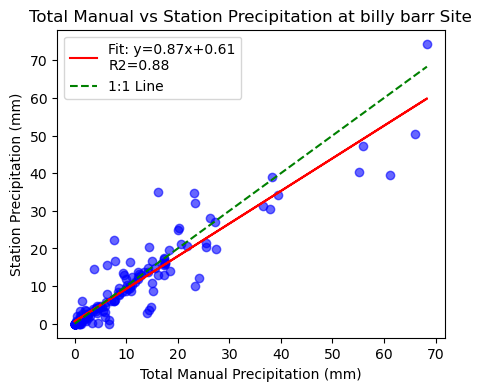

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(bb_comparison_df['Total_Manual_Precipitation_mm'], 
           bb_comparison_df['Station_Precipitation_mm'], 
           color='blue', 
           alpha=0.6)

slope, intercept, r_value, p_value, std_err = stats.linregress(bb_comparison_df['Total_Manual_Precipitation_mm'], 
                                                               bb_comparison_df['Station_Precipitation_mm'])

ax.plot(bb_comparison_df['Total_Manual_Precipitation_mm'], 
        intercept + slope*bb_comparison_df['Total_Manual_Precipitation_mm'], 
        'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}\nR2={r_value**2:.2f}')
ax.plot(bb_comparison_df['Total_Manual_Precipitation_mm'].sort_values(), 
        bb_comparison_df['Total_Manual_Precipitation_mm'].sort_values(), 
        'g--', 
        label='1:1 Line')
ax.legend()

ax.set_title('Total Manual vs Station Precipitation at billy barr Site')
ax.set_xlabel('Total Manual Precipitation (mm)')
ax.set_ylabel('Station Precipitation (mm)')

# print rmse between station and manual
rmse = np.sqrt(np.mean((bb_comparison_df['Station_Precipitation_mm'] - bb_comparison_df['Total_Manual_Precipitation_mm'])**2))
print(f"RMSE between station and manual precipitation: {rmse:.2f} mm")
print(f"R between station and manual precipitation: {r_value:.2f}")
# print bias
bias = np.mean(bb_comparison_df['Station_Precipitation_mm'] - bb_comparison_df['Total_Manual_Precipitation_mm'])
print(f"Bias between station and manual precipitation: {bias:.2f} mm")

Text(0, 0.5, 'Station Precipitation (mm)')

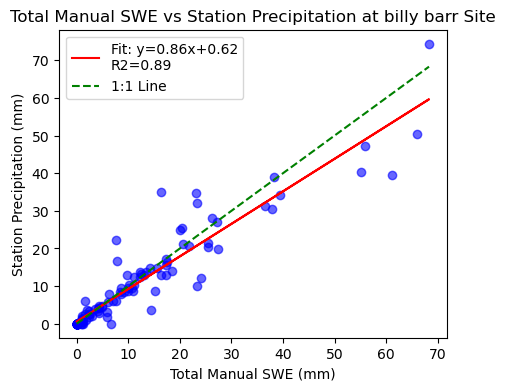

In [11]:
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(bb_comparison_snow_only_df['Manual_SWE_mm'], bb_comparison_snow_only_df['Station_Precipitation_mm'], color='blue', alpha=0.6)

slope, intercept, r_value, p_value, std_err = stats.linregress(bb_comparison_snow_only_df['Manual_SWE_mm'], bb_comparison_snow_only_df['Station_Precipitation_mm'])

ax.plot(bb_comparison_snow_only_df['Manual_SWE_mm'], intercept + slope*bb_comparison_snow_only_df['Manual_SWE_mm'], 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}\nR2={r_value**2:.2f}')
ax.plot(bb_comparison_snow_only_df['Manual_SWE_mm'].sort_values(), bb_comparison_snow_only_df['Manual_SWE_mm'].sort_values(), 'g--', label='1:1 Line')
ax.legend()

ax.set_title('Total Manual SWE vs Station Precipitation at billy barr Site')
ax.set_xlabel('Total Manual SWE (mm)')
ax.set_ylabel('Station Precipitation (mm)')

### SQUIRE comparison

In [12]:
SITE = "gothic"
benchmark = "billy_barr_precip"

# Load dataset as dataframe
full_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in full_ds.data_vars if 'qc' in var]
ds_no_qc = full_ds.drop_vars(qc_vars)

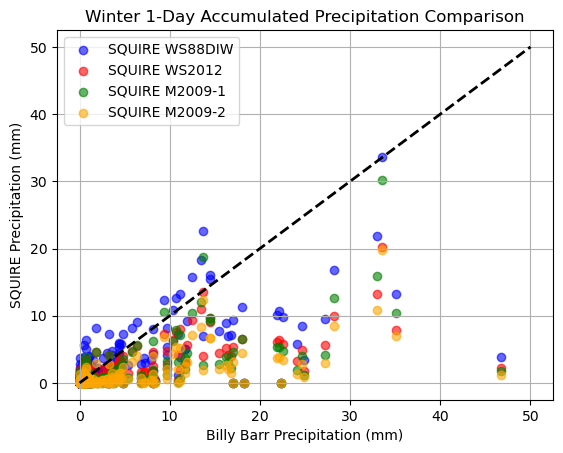

In [13]:
plt.scatter(ds_no_qc['billy_barr_precip'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(), 
            ds_no_qc['sail_squire_ws88diw'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(),
            label='SQUIRE WS88DIW', color='blue', alpha=0.6)
plt.scatter(ds_no_qc['billy_barr_precip'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(), 
            ds_no_qc['sail_squire_ws2012'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(),
            label='SQUIRE WS2012', color='red', alpha=0.6)
plt.scatter(ds_no_qc['billy_barr_precip'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(), 
            ds_no_qc['sail_squire_m2009_1'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(),
            label='SQUIRE M2009-1', color='green', alpha=0.6)
plt.scatter(ds_no_qc['billy_barr_precip'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(), 
            ds_no_qc['sail_squire_m2009_2'].where(ds_no_qc.time.dt.month.isin([12,1,2,3])).resample(time='1D').sum(),
            label='SQUIRE M2009-2', color='orange', alpha=0.6)
plt.plot([0, 50], [0, 50], 'k--', lw=2)
plt.grid()
plt.ylabel('SQUIRE Precipitation (mm)')
plt.xlabel('Billy Barr Precipitation (mm)')
plt.title('Winter 1-Day Accumulated Precipitation Comparison')
plt.legend()

# Accumulation Figures

## Total precipitation comparison

In [14]:
ANALYSIS_TYPE = 'all'  # options: 'all', 'warm', 'cold'

### Gothic

In [15]:
original_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in original_ds.data_vars if 'qc' in var]
gothic_ds_no_qc = original_ds.drop_vars(qc_vars)

In [16]:
SITE = "gothic"
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None if not seasonal analysis
# get time extents for all variable
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[GRIDDED_VARS], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[GRIDDED_VARS].sel(time=gridded_time_slice).resample(time='1D').sum())

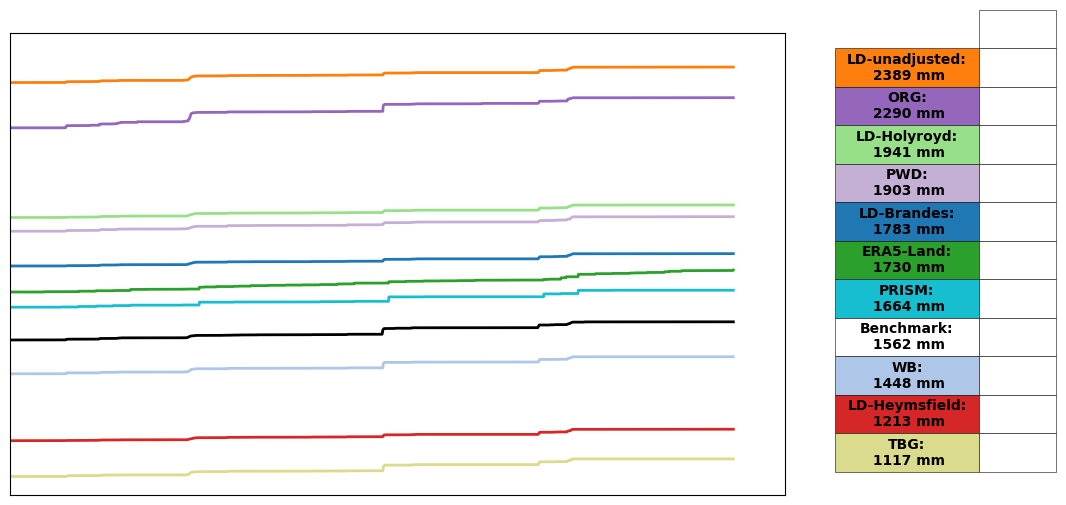

In [17]:
zoom_dict = {'xrange': [pd.to_datetime('2023-05-01'), pd.to_datetime('2023-06-15')], 'yrange': [1000, 2500]}
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, zoom=zoom_dict)

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_all_data_prcp_accum.png


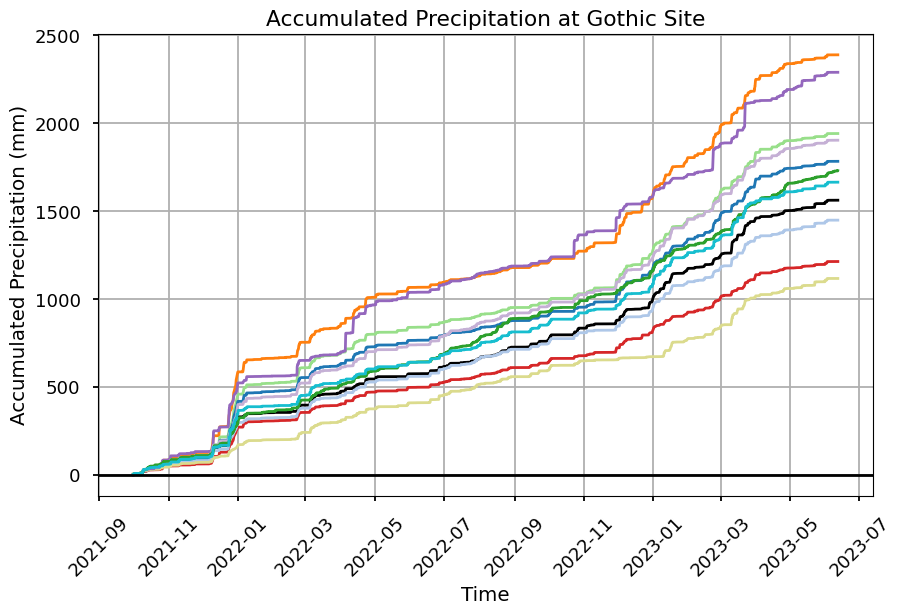

In [18]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [19]:
SITE = "kettle_ponds"

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in original_ds.data_vars if 'qc' in var] + ['precip_type']
kettle_ponds_ds_no_qc = original_ds.drop_vars(qc_vars)

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

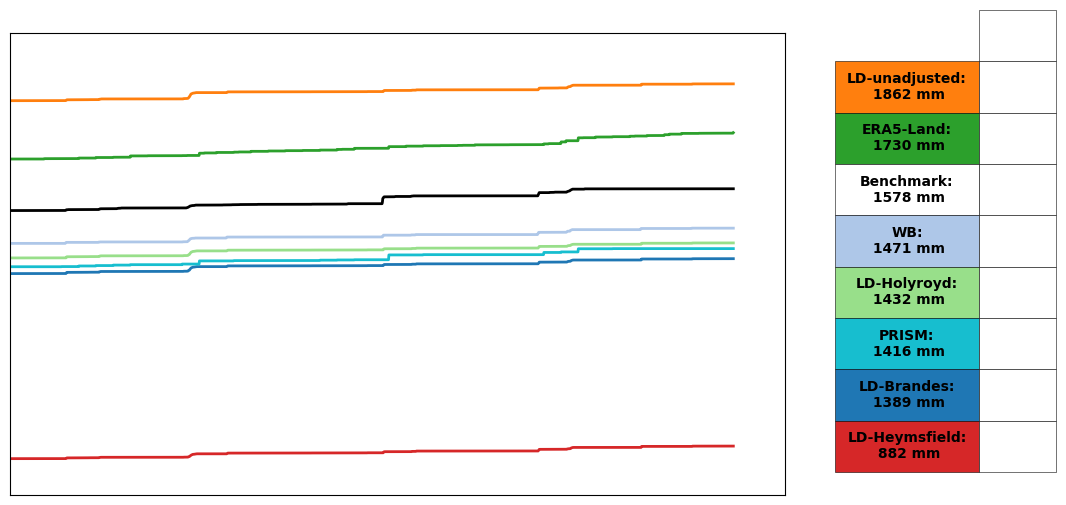

In [20]:
zoom_dict = {'xrange': [pd.to_datetime('2023-05-01'), pd.to_datetime('2023-06-15')], 'yrange': [750, 2000]}
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, zoom=zoom_dict)

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_accum.png


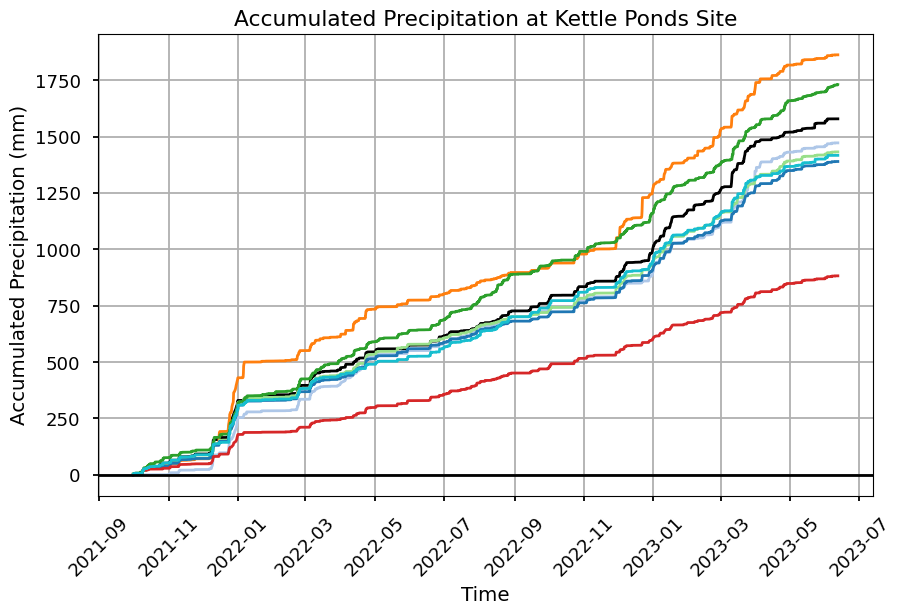

In [21]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

## Water year total precipitation comparison

### Gothic

In [22]:
SITE = "gothic"

#### Water Year 2022

In [23]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2022_prcp_accum.png


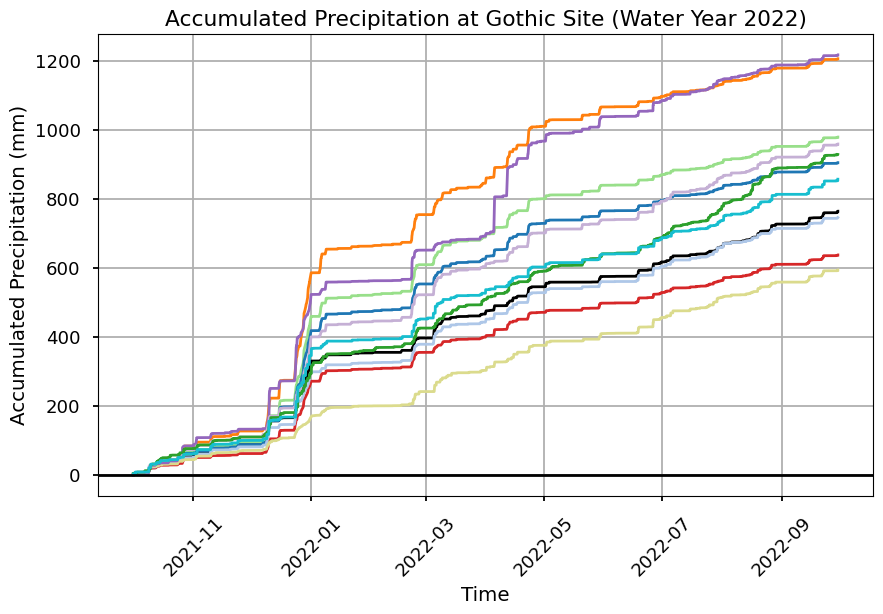

In [24]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

#### Water Year 2023

In [25]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2023_prcp_accum.png


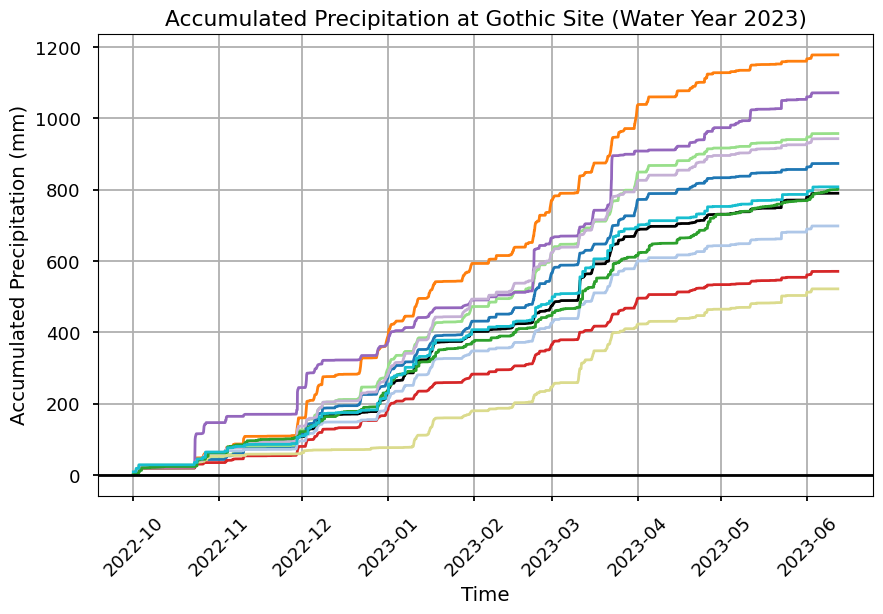

In [26]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded,  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [27]:
SITE = "kettle_ponds"

#### Water Year 2022

In [28]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))

ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2022_prcp_accum.png


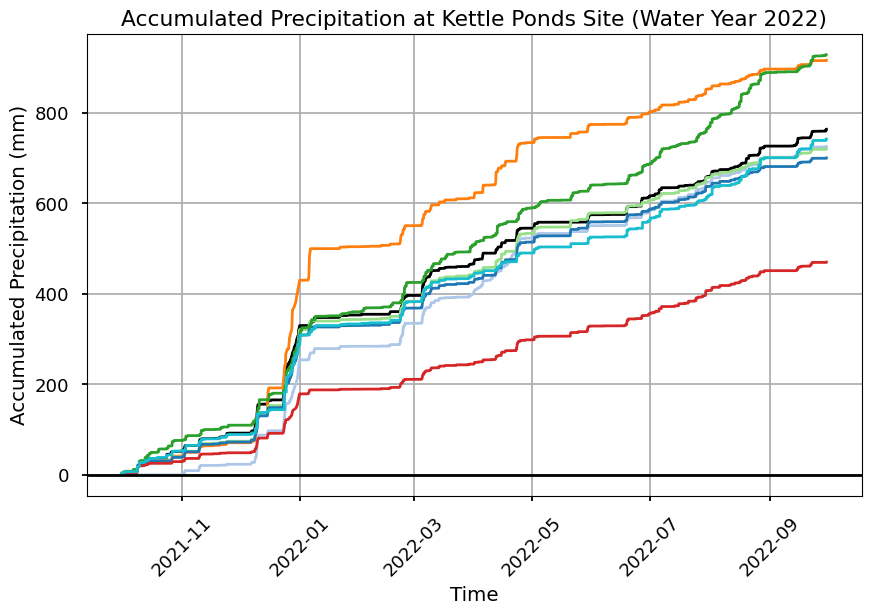

In [29]:
fig = plot_accumulated_precipitation(ds,  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded,  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=True, output_dir=OUTPUT_DIR)

#### Water Year 2023

In [30]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2023_prcp_accum.png


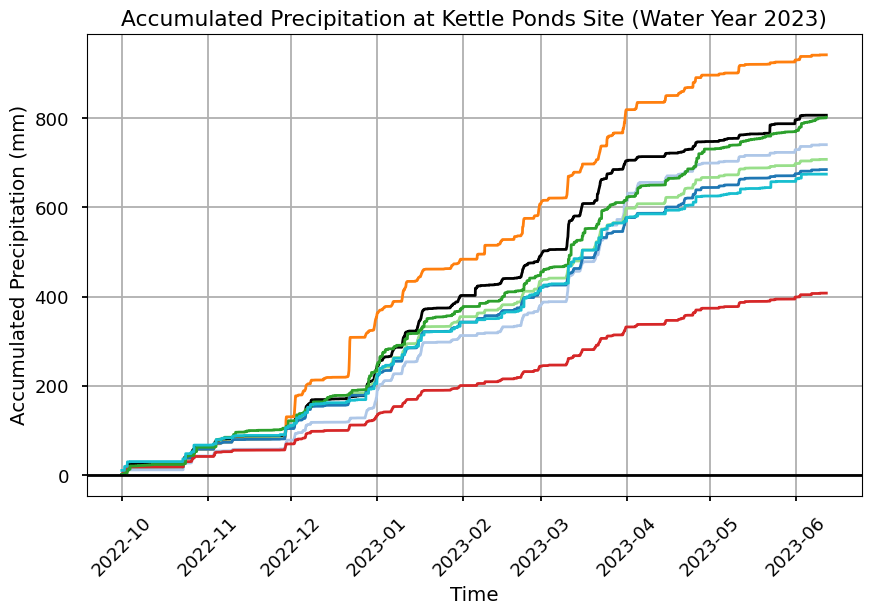

In [31]:
fig = plot_accumulated_precipitation(ds,  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded,  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum',  gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip',  site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias',  gridded=True, output_dir=OUTPUT_DIR,)

## Seasonal total precipitation comparison by water year

### Gothic

In [32]:
SITE = 'gothic'

#### Snow Season (November - May)

In [33]:
ANALYSIS_TYPE = 'snow'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [34]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_snow_season_2022_prcp_accum.png


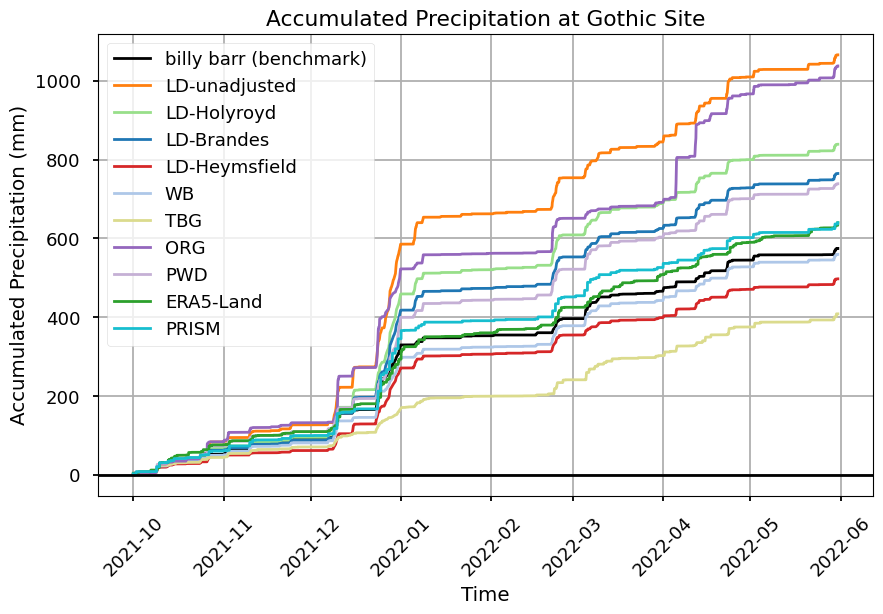

In [35]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [36]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_snow_season_2023_prcp_accum.png


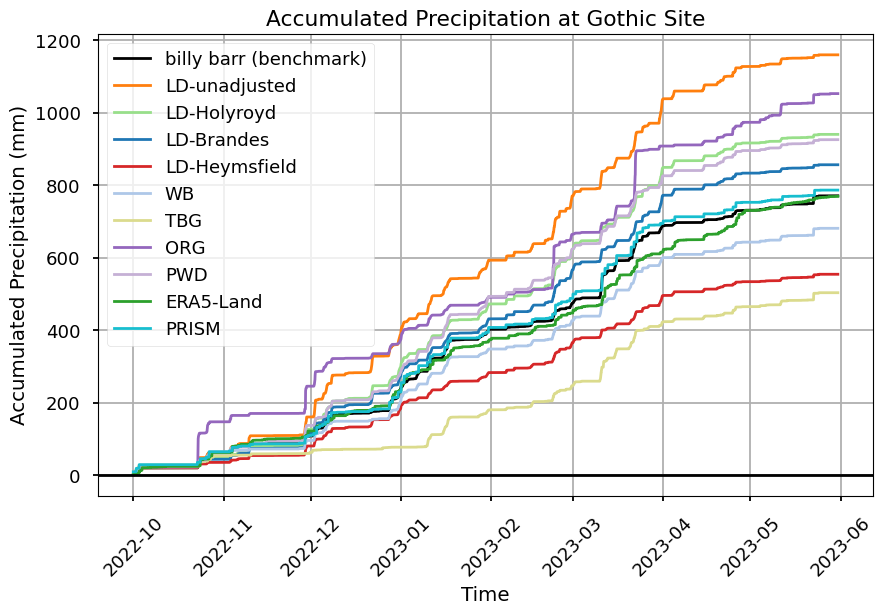

In [37]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

#### Rain Season (June - October)

In [38]:
ANALYSIS_TYPE = 'rain'  # options: 'all', 'rain', 'snow'

##### Water Year 2022

In [39]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_rain_season_2022_prcp_accum.png


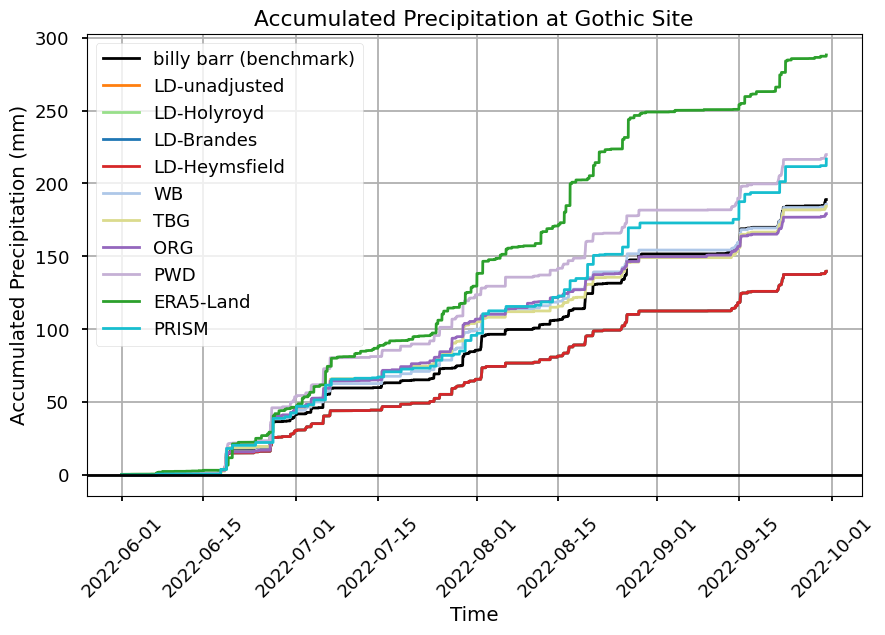

In [40]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [41]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_rain_season_2023_prcp_accum.png


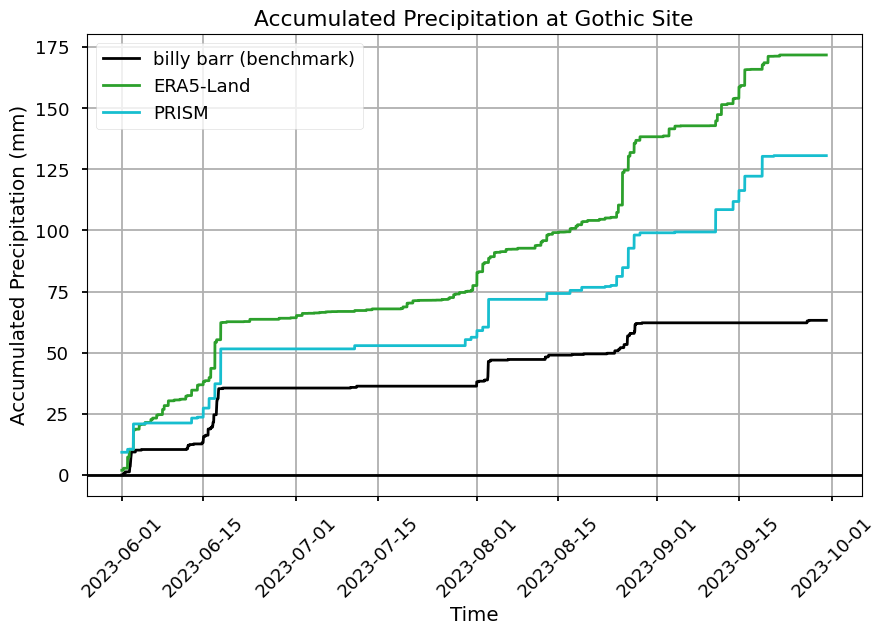

In [42]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

#### Winter

In [43]:
ANALYSIS_TYPE = 'DJFM'

##### Water Year 2022

In [44]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

# limit to only december through march
ds = ds.sel(time=ds['time.month'].isin([12,1,2,3]))
ds_gridded = ds_gridded.sel(time=ds_gridded['time.month'].isin([12,1,2,3]))

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_DJFM_season_2022_prcp_accum.png


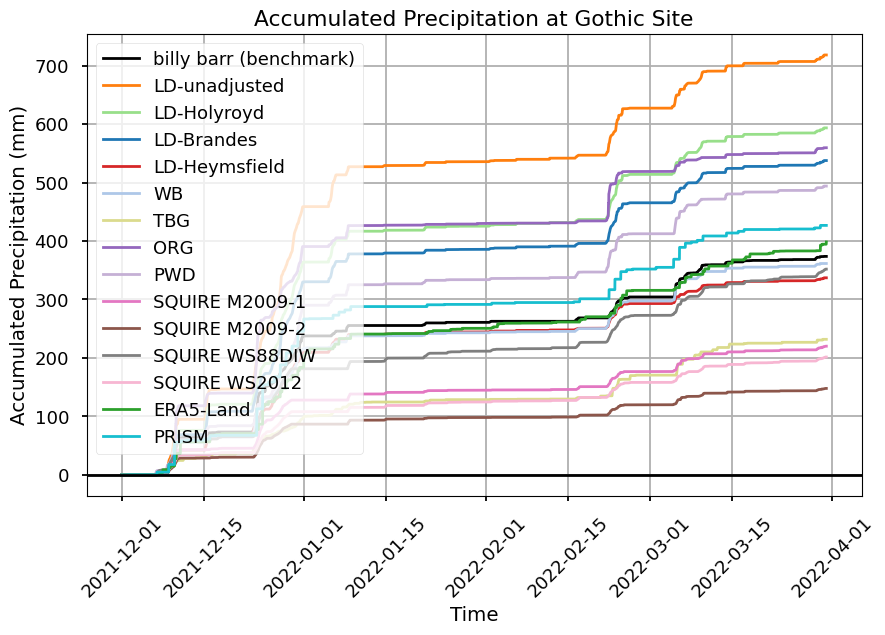

In [45]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [46]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_DJFM_season_2023_prcp_accum.png


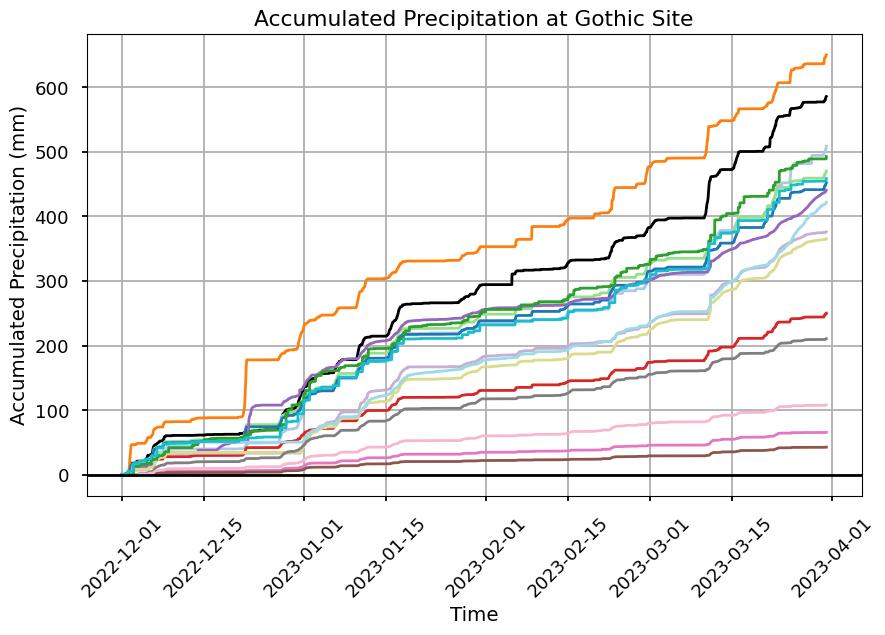

In [47]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [48]:
SITE = "kettle_ponds"

#### Snow Season (November - May)

In [49]:
ANALYSIS_TYPE = 'snow'

##### Water Year 2022

In [50]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_snow_season_2022_prcp_accum.png


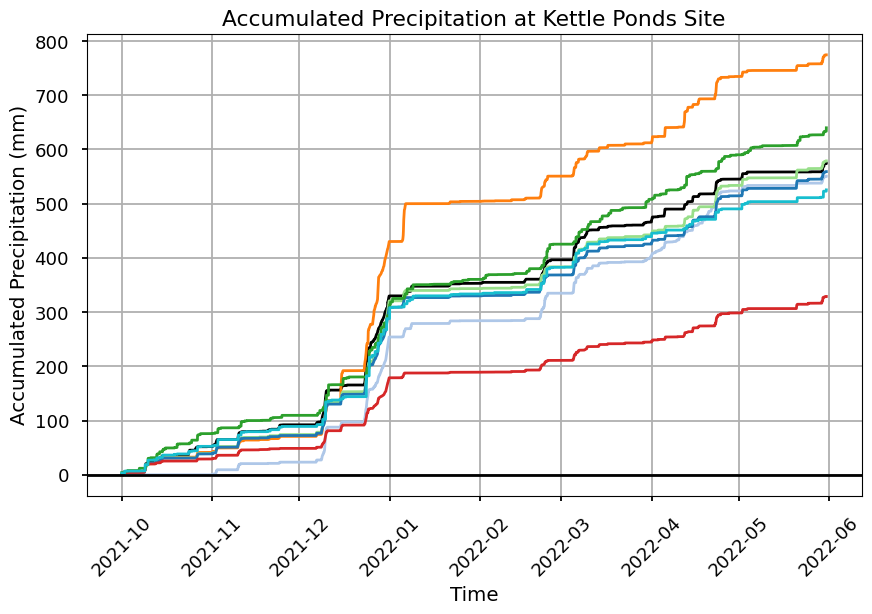

In [51]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

#### Winter

In [52]:
ANALYSIS_TYPE = 'DJFM'  # options: 'all', 'warm', 'snow'

##### Water Year 2022

In [53]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

# limit to only december through march
ds = ds.sel(time=ds['time.month'].isin([12,1,2,3]))
ds_gridded = ds_gridded.sel(time=ds_gridded['time.month'].isin([12,1,2,3]))

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_DJFM_season_2022_prcp_accum.png


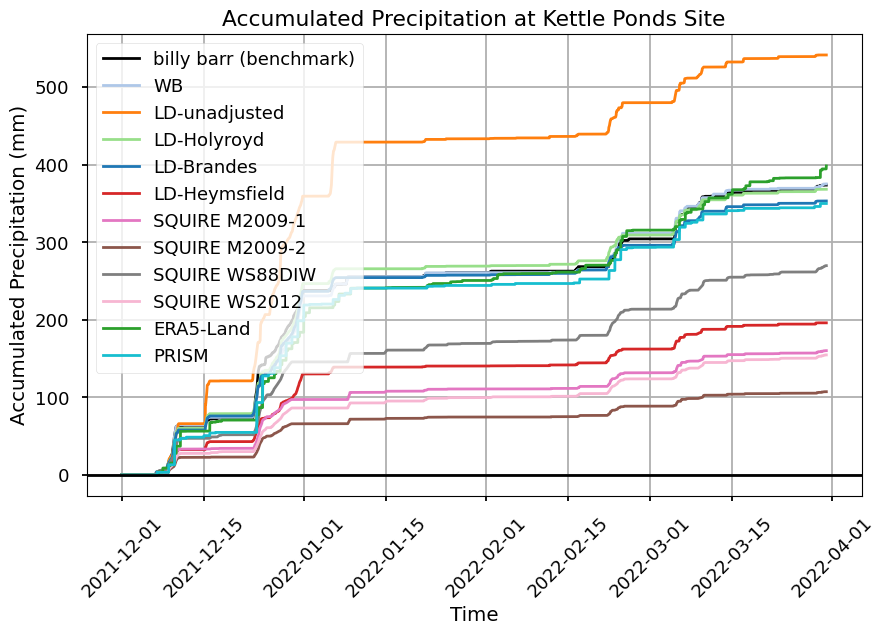

In [54]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, legend=True)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [55]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_DJFM_season_2023_prcp_accum.png


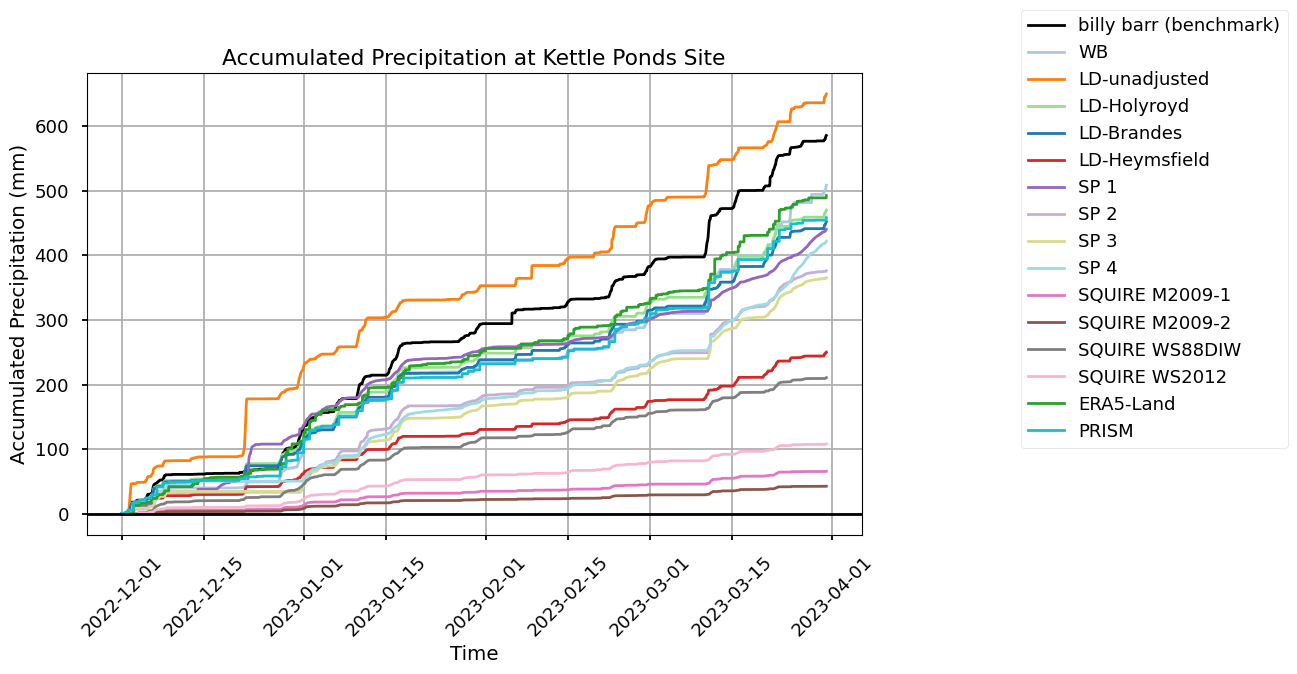

In [56]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

#### Rain Season (June - October)

In [57]:
ANALYSIS_TYPE = 'rain'

##### Water Year 2022

In [58]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_rain_season_2022_prcp_accum.png


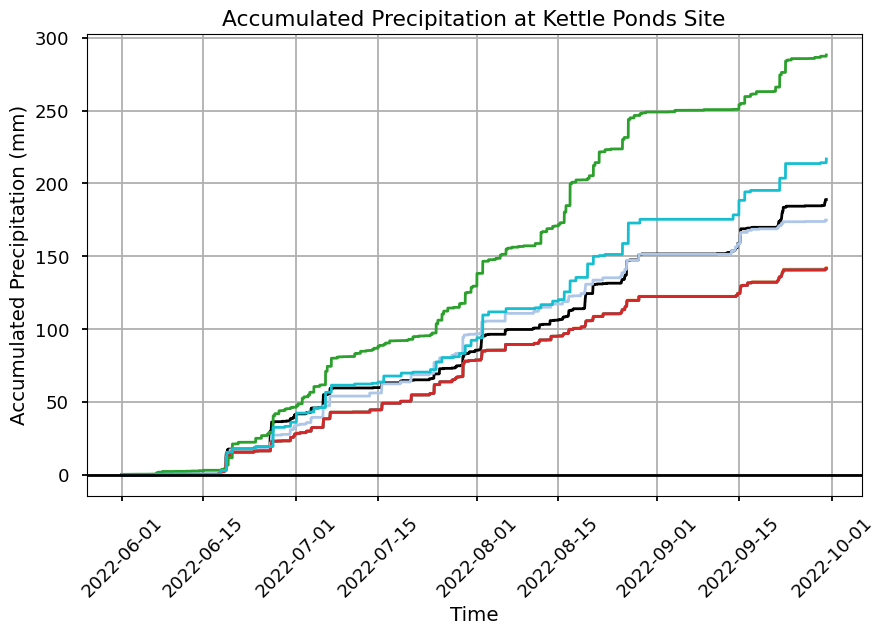

In [59]:
fig = plot_accumulated_precipitation(ds, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_precipitation(ds_gridded, site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', gridded=True, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=False, output_dir=OUTPUT_DIR)

# fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
# save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', gridded=True, output_dir=OUTPUT_DIR)

## Move all generated figures to more specific subdirectories

In [60]:
# 

subdir_prcp = OUTPUT_DIR / "precipitation"
subdir_bias = OUTPUT_DIR / "bias"

for subdir in [subdir_prcp, subdir_bias]:
    if not os.path.exists(subdir):
        os.makedirs(subdir)
    subdir_gothic = subdir / "gothic"
    subdir_kettle = subdir / "kettle_ponds"
    for site_subdir in [subdir_gothic, subdir_kettle]:
        if not os.path.exists(site_subdir):
            os.makedirs(site_subdir)
for filename in os.listdir(OUTPUT_DIR):
    if filename.endswith(".png"):
        if "accum" in filename:
            dest_dir = subdir_prcp
        elif "bias" in filename:
            dest_dir = subdir_bias
        else:
            continue  # skip files that are not prcp or bias
        if "gothic" in filename:
            dest_dir = dest_dir / "gothic"
        elif "kettle_ponds" in filename:
            dest_dir = dest_dir / "kettle_ponds"
        else:
            continue  # skip files that are not for known sites
        src_path = os.path.join(OUTPUT_DIR, filename)
        dest_path = os.path.join(dest_dir, filename)
        os.rename(src_path, dest_path)
        print(f"Moved {filename} to {dest_dir}")

Moved gothic_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved gothic_all_data_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved gothic_rain_season_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved kettle_ponds_snow_season_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/kettle_ponds
Moved kettle_ponds_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/kettle_ponds
Moved gothic_snow_season_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved kettle_ponds_DJFM_season_2023_prcp_accum.png to /home/dlhoga